# Лабораторная работа №2

### Описание задачи и признаков

**Целевой признак** - _Гармония бессмертия_ (числовой)

**Класс задачи** - Регрессия




## Таблица признаков магического портала

### Исходные признаки

| Название признака | Описание | Ограничения значений |
|-------------------|-----------|---------------------|
| **Вектор Мощи** | Позиция магического механизма, управляющего интенсивностью перехода через портал | - |
| **Скорость перехода через портал** | Скорость, с которой портал перемещает объект через пространство | > 0 |
| **Приток Силы Потока** | Поток магической силы, текущий через ядро портала | > 0 |
| **Ритм магического ядра** | Число оборотов магического ядра портала в минуту | > 0 |
| **Поток Энергий** | Число оборотов генератора эфира, преобразующего внешнюю энергию в магическую | > 0 |
| **Сила Левого Потока** | Мощность магического потока через левую сторону портала | > 0 |
| **Сила Правого Потока** | Мощность магического потока через правую сторону портала | > 0 |
| **Пламя Стихий** | Температура магической энергии из высокого магического источника портала (°C) | - |
| **Температура вдоха Истока** | Температура воздуха, входящего в магический ускоритель портала (°C) | - |
| **Температура выдоха Истока** | Температура воздуха, исходящего из магического ускорителя портала (°C) | - |
| **Приток давления Выдоха Истока** | Давление магического потока на выходе из магического источника высокого давления | > 0 |
| **Давление вдоха Истока** | Давление воздуха, входящего в магический ускоритель | > 0 |
| **Давление выдоха Истока** | Давление воздуха, исходящего из магического ускорителя | > 0 |
| **Древний Ветер** | Давление древней магической энергии, покидающей портал | > 0 |
| **Печать Чародея** | Параметр управления магическим впрыском в сердце портала (%) | 0-100% |
| **Эмульсия Истока** | Количество магического топлива, подпитывающего портал | > 0 |
| **Дыхание Истока** | Коэффициент степени угасания магического ускорителя | - |
| **Гармония Бессмертия** | Коэффициент состояния магического ядра портала и его стабильности | - |
| **Тип Вектора Мощи** | Метка типа позиции магического механизма | Категориальный |

### Новые признаки из формул

| Название признака | Формула | Описание | Ограничения |
|-------------------|---------|-----------|-------------|
| **Совокупная мощность потоков** | `Сила Левого Потока + Сила Правого Потока` | Общая мощность левого и правого потоков | > 0 |
| **Суммарная сила всех потоков** | `Сила Левого Потока + Сила Правого Потока + Приток Силы Потока` | Полная мощность всех магических потоков | > 0 |
| **Общая сила ядра** | `Ритм магического ядра × Приток Силы Потока` | Показатель общей мощности ядра портала | > 0 |
| **Общее давление на выходе** | `Приток давления Выдоха Истока + Давление выдоха Истока` | Суммарное давление на выходе системы | > 0 |
| **Магическая производительность** | `Скорость перехода через портал ÷ Эмульсия Истока` | Эффективность использования топлива для перехода | > 0 |
| **Эффективность ядра** | `Общая сила ядра ÷ Эмульсия Истока` | Эффективность работы ядра относительно расхода топлива | > 0 |
| **Степень износа** | `Дыхание Истока ÷ Гармония Бессмертия` | Отношение угасания к стабильности ядра | ≠ 0 (деление на ноль) |
| **Расхождение стабильности** | `\|Дыхание Истока - Гармония Бессмертия\|` | Абсолютное значение расхождения в стабильности | ≥ 0 |
| **Баланс угасания** | `(Дыхание Истока - Гармония Бессмертия) ÷ Скорость перехода через портал` | Нормированное расхождение стабильности | ≠ 0 (деление на ноль) |


**Невозможно применить для решения исходной задачи:**
- **Магическая мощность** - отсутствует конкретная формула расчета

In [82]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import missingno as msn

In [83]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Начальный этап обработки данных

#### Загрузка

In [84]:
import pandas as pd

In [85]:
df = pd.read_csv('portal_data.csv', sep='|', header=0, encoding='cp1251',)

In [86]:
df

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,7.584,464.006,736,-,1.096,Не определено,5.947,-,7.137,0.082,0.95,0.975,Слабый,0
1,2.088,-,6960.180,144.111767,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый,1
2,3.144,4.6299600000000005,8379.229,145.220853,7111.811,60.358,60.358,606.002,736,-,1.389,Не определено,7.574,-,13.086,0.259,0.95,0.975,Ниже среднего,2
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,113.774,661.471,736,-,1.658,Не определено,9.007,-,18.109,0.358,0.95,0.975,Ниже среднего,3
4,5.140,7.7166,21636.432,201.513586,8494.777,175.306,175.306,731.494,736,645.642,2.078,Не определено,11.197,1.026,26.373,0.522,0.95,0.975,Выше среднего,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11929,5.140,7.7166,21624.934,201.516623,8470.013,175.239,175.239,681.658,736,628.95,2.087,Не определено,10.990,1.027,23.803,0.471,1.00,1.000,Выше среднего,11929
11930,6.175,9.25992,29763.213,241.561772,8800.352,245.954,245.954,747.405,736,-,2.512,Не определено,13.109,-,32.671,0.647,1.00,1.000,Выше среднего,11930
11931,7.148,10.80324,39003.867,280.444950,9120.889,332.389,332.389,796.457,736,680.393,2.982,Не определено,15.420,1.036,42.104,0.834,1.00,1.000,Сильный,11931
11932,8.206,12.34656,50992.579,323.315332,9300.274,438.024,438.024,892.945,736,-,3.594,Не определено,18.293,-,58.064,1.149,1.00,1.000,Сильный,11932


### Приведение к типам данных

In [87]:
numeric_columns = [
    'Вектор Мощи', 'Скорость перехода через портал', 'Приток Силы Потока',
    'Ритм магического ядра', 'Поток Энергий', 'Сила Левого Потока',
    'Сила Правого Потока', 'Пламя Стихий', 'Температура вдоха Истока',
    'Температура выдоха Истока', 'Приток давления Выдоха Истока',
    'Давление вдоха Истока', 'Давление выдоха Истока', 'Древний Ветер',
    'Печать Чародея', 'Эмульсия Истока', 'Дыхание Истока', 'Гармония Бессмертия'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [88]:
df

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,7.584,464.006,736,NaN,1.096,NaN,5.947,NaN,7.137,0.082,0.95,0.975,Слабый,0
1,2.088,NaN,6960.180,144.111767,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый,1
2,3.144,4.62996,8379.229,145.220853,7111.811,60.358,60.358,606.002,736,NaN,1.389,NaN,7.574,NaN,13.086,0.259,0.95,0.975,Ниже среднего,2
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,113.774,661.471,736,NaN,1.658,NaN,9.007,NaN,18.109,0.358,0.95,0.975,Ниже среднего,3
4,5.140,7.71660,21636.432,201.513586,8494.777,175.306,175.306,731.494,736,645.642,2.078,NaN,11.197,1.026,26.373,0.522,0.95,0.975,Выше среднего,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11929,5.140,7.71660,21624.934,201.516623,8470.013,175.239,175.239,681.658,736,628.950,2.087,NaN,10.990,1.027,23.803,0.471,1.00,1.000,Выше среднего,11929
11930,6.175,9.25992,29763.213,241.561772,8800.352,245.954,245.954,747.405,736,NaN,2.512,NaN,13.109,NaN,32.671,0.647,1.00,1.000,Выше среднего,11930
11931,7.148,10.80324,39003.867,280.444950,9120.889,332.389,332.389,796.457,736,680.393,2.982,NaN,15.420,1.036,42.104,0.834,1.00,1.000,Сильный,11931
11932,8.206,12.34656,50992.579,323.315332,9300.274,438.024,438.024,892.945,736,NaN,3.594,NaN,18.293,NaN,58.064,1.149,1.00,1.000,Сильный,11932


In [89]:
df['Тип Вектора Мощи'] = df['Тип Вектора Мощи'].astype('category')

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Вектор Мощи                     11934 non-null  float64 
 1   Скорость перехода через портал  10731 non-null  float64 
 2   Приток Силы Потока              11934 non-null  float64 
 3   Ритм магического ядра           11934 non-null  float64 
 4   Поток Энергий                   11934 non-null  float64 
 5   Сила Левого Потока              11934 non-null  float64 
 6   Сила Правого Потока             11934 non-null  float64 
 7   Пламя Стихий                    11934 non-null  float64 
 8   Температура вдоха Истока        11934 non-null  int64   
 9   Температура выдоха Истока       2387 non-null   float64 
 10  Приток давления Выдоха Истока   11934 non-null  float64 
 11  Давление вдоха Истока           2439 non-null   float64 
 12  Давление выдоха Ис

In [91]:
df.describe()

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Номер пометки
count,11934.000000,10731.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.0,2387.000000,11934.000000,2439.000000,11934.000000,2387.000000,11934.000000,11934.000000,11934.00000,11934.0000,11934.000000
mean,5.166667,7.721490,27247.498685,223.711688,8200.947312,227.335768,227.335768,735.495446,736.0,646.092576,2.352963,1.394603,12.297123,1.029413,33.641261,0.662440,0.97500,0.9875,5966.500000
std,2.626388,3.993642,22148.613155,81.061874,1091.315507,200.495889,200.495889,173.680552,0.0,71.394305,1.084770,0.000000,5.337448,0.010217,25.841363,0.507132,0.01472,0.0075,3445.193391
min,1.138000,1.543320,253.547000,136.939406,6589.002000,5.304000,5.304000,442.364000,736.0,542.994000,1.093000,1.394603,5.828000,1.019000,0.000000,0.068000,0.95000,0.9750,0.000000
25%,3.144000,4.629960,8375.883750,145.220958,7058.324000,60.317000,60.317000,589.872750,736.0,579.362000,1.389000,1.394603,7.447250,1.020000,13.677500,0.246000,0.96200,0.9810,2983.250000
50%,5.140000,7.716600,21630.659000,201.514947,8482.081500,175.268000,175.268000,706.038000,736.0,636.963000,2.083000,1.394603,11.092000,1.026000,25.276500,0.496000,0.97500,0.9875,5966.500000
75%,7.148000,10.803240,39001.426750,280.447777,9132.606000,332.364750,332.364750,834.066250,736.0,692.152000,2.981000,1.394603,15.658000,1.036000,44.552500,0.882000,0.98800,0.9940,8949.750000
max,9.300000,13.889880,72784.872000,372.879926,9797.103000,645.249000,645.249000,1115.797000,736.0,788.433000,4.560000,1.394603,23.140000,1.052000,92.556000,1.832000,1.00000,1.0000,11933.000000


### Анализ пропусков

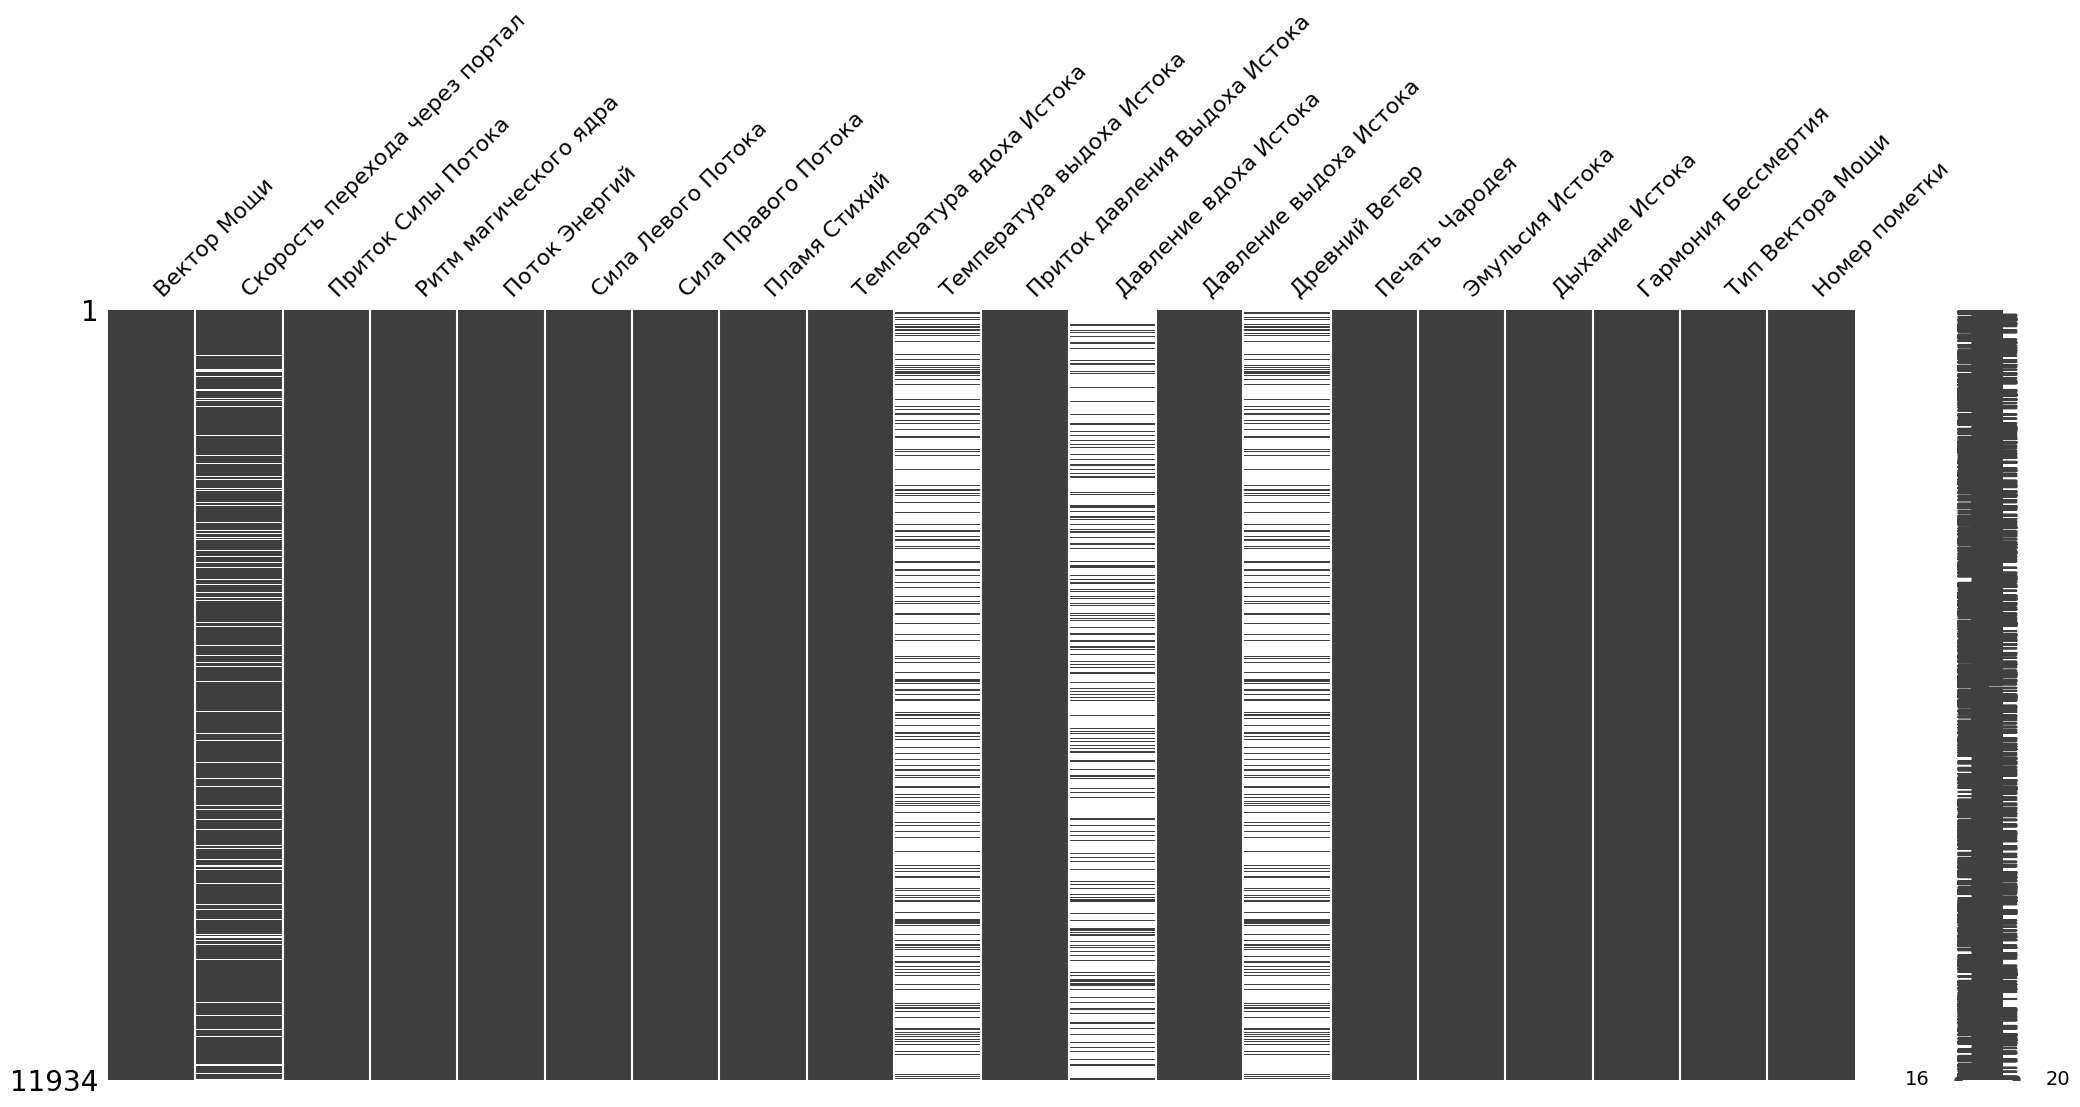

In [92]:
msn.matrix(df);

In [93]:
sum(df['Скорость перехода через портал'].isna())/df.shape[0]*100

10.08044243338361

#### Уникальные номера
```Номер пометки```  можно отбросить, так как он дублирует индексацию строк в датафрейме

In [94]:
df = df.drop(columns=['Температура выдоха Истока', 'Давление вдоха Истока', 'Древний Ветер','Номер пометки'])

#### Разделение на выборки

In [96]:
X_train, X_test, Y_train, Y_test = train_test_split(df.drop(columns=['Гармония Бессмертия']), df['Гармония Бессмертия'], test_size=0.7)